# Data Engineering One

This is an intro to **Jupyter Notebooks** and do **Data Engineering**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the Full Ontario Retail Sales Dataset




In [2]:
# Load the sales dataset
from src.Load_data import sales_data_collect

# Load the sales data
sales_data = sales_data_collect()

# Display the first 5 rows
sales_data.head(5)

,order_id,date,customer_id,product_id,product,product_category,price,quantity,coupon_code,discount_pct,payment_method,shipping_city,shipping_province,sales_amount
0,ON100762,2025-01-03,C11886,P2378,Lip Balm,Beauty,63.41,6,NO_COUPON,0.0,Credit Card,London,ON,380.46
1,ON100888,2025-01-03,C10858,P1339,Air Fryer,Home & Kitchen,55.39,5,WELCOME5,5.0,Interac,Guelph,ON,263.10
2,ON100375,2025-01-04,C12057,P8749,Coffee Maker,Home & Kitchen,81.91,3,NO_COUPON,0.0,Credit Card,Hamilton,ON,245.73
3,ON100459,2025-01-04,C10823,P9067,Baseball Cap,Apparel,93.35,3,NO_COUPON,0.0,Debit Card,Vaughan,ON,280.05
4,ON100833,2025-01-04,C10951,P1044,Cereal,Grocery,14.40,3,NO_COUPON,0.0,Credit Card,Scarborough,ON,43.20


### Part 2 - Perform some Exploratory Data Analysis on the basic Data Set



**#### Query 1**

query on the existing **"sales_data"** DataFrame for extracting sales transactions from **2025**.


In [3]:

import pandas as pd
# Make sure the date column is in datetime format
sales_data["date"] = pd.to_datetime(sales_data["date"], errors="coerce")

# Keep only the sales transactions from 2025
sales_2025 = sales_data[sales_data["date"].dt.year == 2025].copy()

# Show the results
sales_2025.head(3)

,order_id,date,customer_id,product_id,product,product_category,price,quantity,coupon_code,discount_pct,payment_method,shipping_city,shipping_province,sales_amount
0,ON100762,2025-01-03,C11886,P2378,Lip Balm,Beauty,63.41,6,NO_COUPON,0.0,Credit Card,London,ON,380.46
1,ON100888,2025-01-03,C10858,P1339,Air Fryer,Home & Kitchen,55.39,5,WELCOME5,5.0,Interac,Guelph,ON,263.10
2,ON100375,2025-01-04,C12057,P8749,Coffee Maker,Home & Kitchen,81.91,3,NO_COUPON,0.0,Credit Card,Hamilton,ON,245.73


**#### Query 2**

 a query on the existing **"sales_data"** DataFrame for extracting the **top 10 sales transactions based on sales amount**.


In [4]:
# Sort the sales data by sales_amount from highest to lowest
top_sales = sales_data.sort_values("sales_amount", ascending=False).copy()

# Show the top 10 sales transactions
top_sales.head(10)

,order_id,date,customer_id,product_id,product,product_category,price,quantity,coupon_code,discount_pct,payment_method,shipping_city,shipping_province,sales_amount
659,ON100643,2026-02-01,C10525,P8125,Wireless Mouse,Electronics,227.81,18,BOGO,20.0,Debit Card,Ottawa,ON,3280.46
865,ON100092,2026-05-26,C11494,P5614,T-Shirt,Apparel,99.84,23,NO_COUPON,0.0,Credit Card,Scarborough,ON,2296.32
586,ON100224,2025-12-18,C11869,P8503,USB-C Hub,Electronics,202.34,8,NO_COUPON,0.0,Credit Card,Hamilton,ON,1618.72
477,ON100512,2025-10-16,C11970,P7462,T-Shirt,Apparel,54.73,26,WELCOME5,5.0,Interac,Hamilton,ON,1351.83
646,ON100664,2026-01-22,C10365,P5118,Wireless Keyboard,Electronics,232.47,5,FREESHIP,0.0,Interac,Windsor,ON,1162.35
531,ON100982,2025-11-16,C11631,P4966,Face Cleanser,Beauty,69.97,16,NO_COUPON,0.0,Debit Card,Markham,ON,1119.52
521,ON100707,2025-11-11,C12178,P3040,Wireless Mouse,Electronics,223.00,5,NO_COUPON,0.0,Credit Card,Guelph,ON,1115.00
442,ON100210,2025-09-30,C11552,P6116,Webcam,Electronics,135.55,8,NO_COUPON,0.0,Credit Card,Cambridge,ON,1084.40
785,ON100396,2026-04-17,C11764,P9395,Resistance Bands,Sports,184.93,7,BOGO,20.0,Debit Card,Waterloo,ON,1035.61
239,ON100146,2025-05-23,C11805,P6664,Wireless Mouse,Electronics,241.49,5,SAVE15,15.0,PayPal,Kitchener,ON,1026.33


**#### Query 3**

a query on the existing **"sales_data"** DataFrame for finding the **total sales amount for each product category**.


In [5]:
# Calculate total sales for each product category
category_sales = sales_data.groupby("product_category")["sales_amount"].sum()

# Sort categories from highest to lowest sales
category_sales = category_sales.sort_values(ascending=False)

# Show the results
category_sales

product_category
Electronics       61828.50
Apparel           43336.75
Home & Kitchen    33686.71
Sports            23429.61
Beauty            11573.14
Grocery            9088.99
Name: sales_amount, dtype: float64

#### Query 4

Add Python code to run a query on the existing *"sales_data"* DataFrame for finding the *top 10 cities based on total sales amount*.

In [6]:
from src.Load_data import sales_data_collect

# Load the sales data
sales_data = sales_data_collect()

# Calculate total sales for each city
city_sales = sales_data.groupby("shipping_city")["sales_amount"].sum()

# Sort cities from highest to lowest sales
city_sales = city_sales.sort_values(ascending=False)

# Show the top 10 cities
city_sales.head(10)

shipping_city
Hamilton       14630.30
Waterloo       14257.63
Cambridge      13712.03
Kitchener      13695.29
Windsor        13618.03
Scarborough    13613.58
London         13106.64
Markham        12647.38
Toronto        12530.12
Guelph         11453.31
Name: sales_amount, dtype: float64

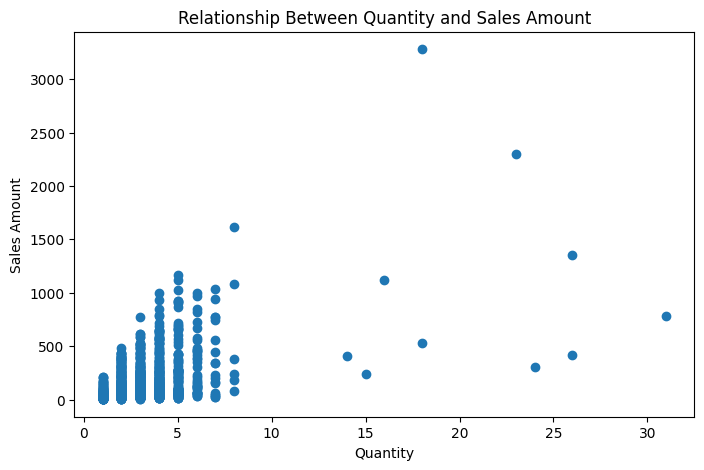

In [7]:

# Create a scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    sales_data["quantity"],
    sales_data["sales_amount"]
)

# Add labels and title
plt.xlabel("Quantity")
plt.ylabel("Sales Amount")
plt.title("Relationship Between Quantity and Sales Amount")

# Show the chart
plt.show()

**Trend Line**

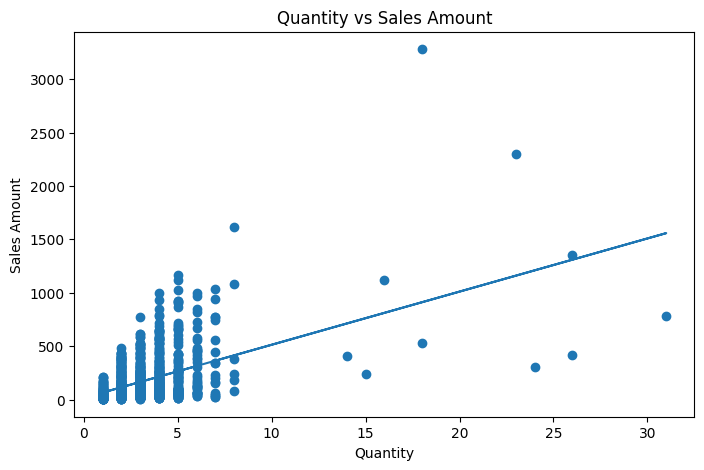

In [8]:

x = sales_data["quantity"]
y = sales_data["sales_amount"]

# Calculate trend line
z = np.polyfit(x, y, 1)
trend = np.poly1d(z)

plt.figure(figsize=(8, 5))

plt.scatter(x, y)
plt.plot(x, trend(x))

plt.xlabel("Quantity")
plt.ylabel("Sales Amount")
plt.title("Quantity vs Sales Amount")

plt.show()